                               Objective 
The aim of this notebook is to train a machine learning model that will isolate anomalies (fraud), check model performance, estimate feature importance in relation to predicting anomalies and lastly how and why a single transactiion was flagged as an anomaly.

              Modelling
This will involve the process of creating an algorithym that will learn an identity of the data points i.e whether a transaction is normal or potential fraud by isolating them levereging on isoforest model. This means it will map the density of transactions and label a transaction as fraud if it is isolated from the dense transactions.   

In [ ]:
import optuna 
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score 
from sklearn.metrics import precision_recall_curve, auc 
import seaborn as sns 
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100 


uploading our feature engineered dataset and displaying its content.

In [19]:
df = pd.read_csv(r'./bankfeature_engineeredCsv.csv')
df.head()

,Unnamed: 0,TransactionID,TransactionAmount,TimeChange_mins,AccountBalance,Load_and_go_flag,Debit_Balance_ratio,High_amount_for_job,TransactionVelocity_30mins,TransactionType_freq,Channel_freq,CustomerOccupation_freq,CustomerAge_map
0,0,TX001313,47.79,0.000000,1649.92,0,0.028965,0,1.0,0.773885,0.345541,0.261545,2
1,1,TX002017,212.97,86396.233333,4180.40,0,0.050945,0,1.0,0.773885,0.322850,0.248806,3
2,2,TX002121,476.99,-351472.450000,1154.48,0,0.413164,0,1.0,0.773885,0.322850,0.261545,2
3,3,TX000021,59.32,0.000000,5750.89,0,0.010315,0,1.0,0.773885,0.345541,0.238455,3
4,4,TX001477,12.62,-331225.100000,6420.47,0,0.001966,0,1.0,0.773885,0.345541,0.251194,2


                                      Isolation Forest 
This is an unsupervised machine leraning model that detect anomalies by following these steps:
1. it select a feature and based on the maximum and minimum values it splits it into a tree 
2. It keeps splitting until each point is isolated in its own space a process called recursive partitioning 
3. finally a point is given a score of 1 if it's isolated fast due to few tree splits making it an anomaly but if a feature takes longer tree splits and its harder to isolate, then it is considered a normal data point.


I used random search  for hyperparameter tuning i.e setting the optimum values for parameters like contamination(threshold for a point to be considered outlier), max-samples(number of rows used to build a tree) and n_estimators(number of trees) and fiited the model onthe optimized paramaters. 

Silhoute score is used to check model performance in separating anomalies from normal data points since isoforest is an unsupervised learning model.If the score is better tahn best_score which I set -1, then the parameters and best score are updated to the new one where model performance is higher. 


Finally, the model is trained with updated parameters and raw anomaly score is obtained by by levereging decision function where positive values are normal values and negative values are anomalies


In [20]:
import random 
n_estimators_range = [100, 200, 300, 400, 500]
max_samples_range = [0.2, 0.5, 0.8]
contamination_range = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06]
best_score = -1.0 
best_params = {}
dff = df.copy()
dff = dff.drop(columns = ['TransactionID'], axis=1)
features = dff.columns.tolist()
for _ in range(20):
    params = {'n_estimators': random.choice(n_estimators_range), 'max_samples': random.choice(max_samples_range), 'contamination':random.choice(contamination_range), 'random_state': 42}
    model = IsolationForest(**params)
    preds = model.fit_predict(dff[features])
    score = silhouette_score(dff[features], preds)
    if score > best_score:
        best_score = score 
        best_params = params 

final_model = IsolationForest(**best_params, n_jobs=-1)
df['isAnomaly'] = final_model.fit_predict(dff[features])
df['Anomaly_score'] = final_model.decision_function(dff[features])


finally, a score is considered an anomaly if its negative and a normal one if its positive by mapping i.e 1 as 'Normal' and -1 as 'anomaly/potential fraud'.

In [21]:
suspicious_activity = df[df['isAnomaly'] == -1]
df['Anomaly_status'] = df['isAnomaly'].map({1: 'Normal', -1: 'Potential fraud'})


In [22]:
df.Anomaly_status.value_counts()

Anomaly_status
Normal             2486
Potential fraud      26
Name: count, dtype: int64

The results are  higky inbalanced with anomalies being 26 and normal points being 2,486. 



                          Anomalies visuailisation and feature correlation to anomaly score


C:\Users\test\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\test\AppData\Local\Temp\ipykernel_10228\249979752.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='TimeChange_mins', hue='Anomaly_status', fill=True, common_norm=False, palette={'Normal': 'skyblue', 'Potential fraud': 'crimson'}, log_scale=True, ax=axes[0, 1])
C:\Users\test\AppData\Local\Temp\ipykernel_10228\249979752.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='Anomaly_status', y='Debit_Balance_ratio', palette={'Normal': 'skyblue', 'Potential fraud': 'crimson'}, ax=axes[1, 0])


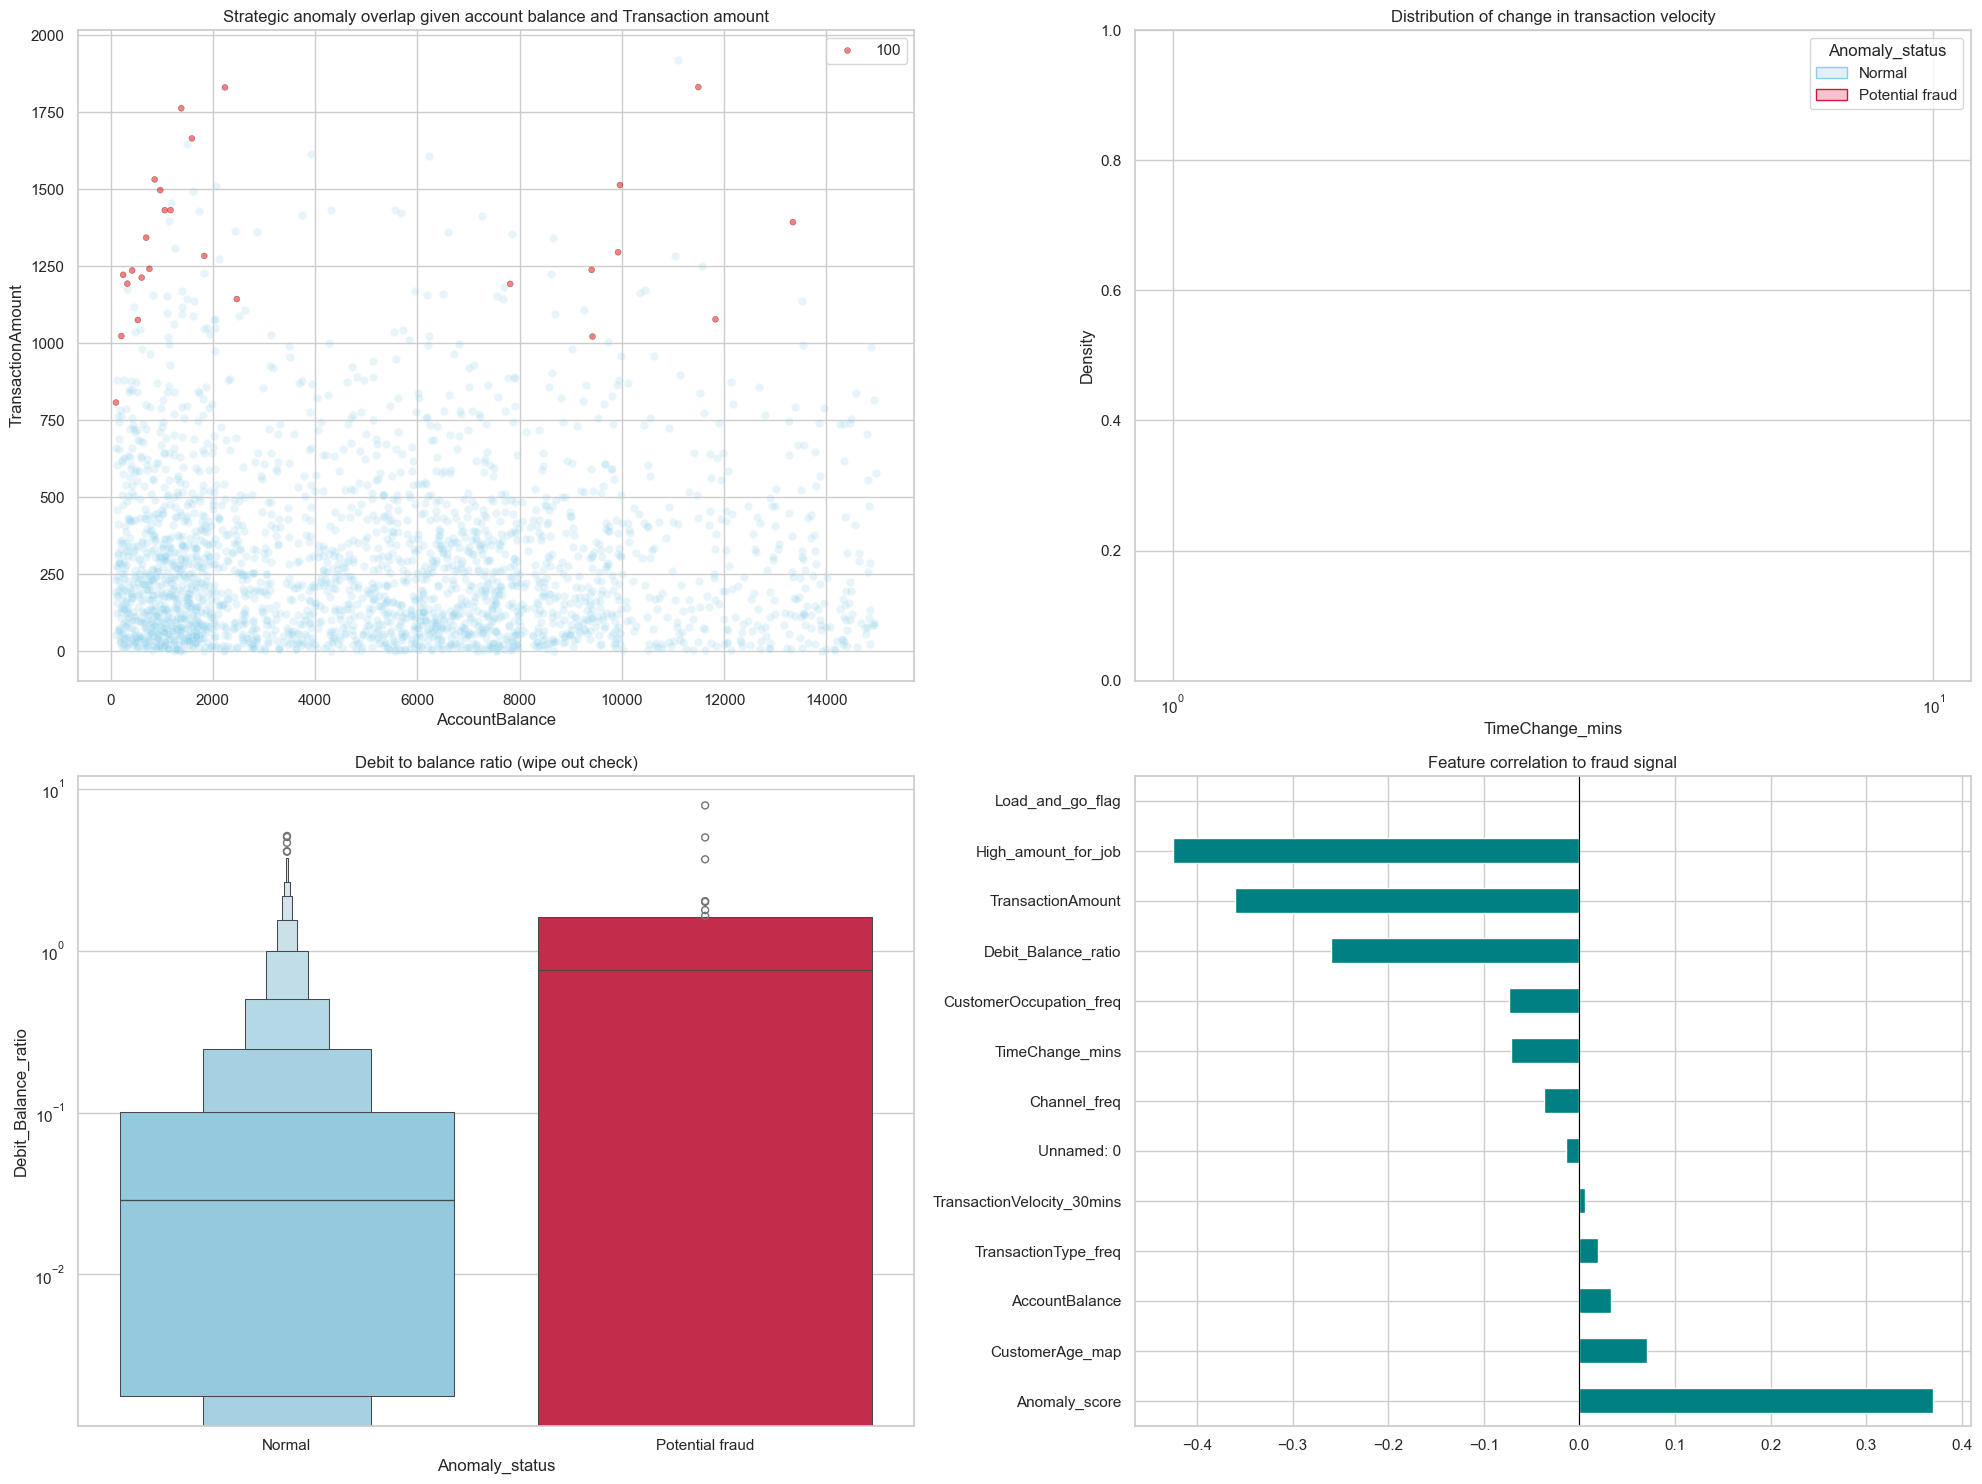

In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(20, 15))
plt.subplots_adjust(hspace=0.3, wspace=0.2)
sns.scatterplot(data = df[df['Anomaly_status'] == 'Normal'], x='AccountBalance', y = 'TransactionAmount', alpha=0.2, color='skyblue', ax=axes[0, 0])
sns.scatterplot(data=df[df['Anomaly_status'] == 'Potential fraud'], x='AccountBalance', y='TransactionAmount', alpha=0.5, color='red', edgecolor='black', size=100, ax=axes[0, 0])
axes[0, 0].set_title("Strategic anomaly overlap given account balance and Transaction amount")

sns.kdeplot(data=df, x='TimeChange_mins', hue='Anomaly_status', fill=True, common_norm=False, palette={'Normal': 'skyblue', 'Potential fraud': 'crimson'}, log_scale=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of change in transaction velocity')

sns.boxenplot(data=df, x='Anomaly_status', y='Debit_Balance_ratio', palette={'Normal': 'skyblue', 'Potential fraud': 'crimson'}, ax=axes[1, 0])
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Debit to balance ratio (wipe out check)')

numeric_df = df.select_dtypes(include=['number']).drop(columns=['Unnamed:0'], errors='ignore')
target_corr = numeric_df.corr()['isAnomaly'].sort_values(ascending=False).drop('isAnomaly')
target_corr.plot(kind='barh', color='teal', ax=axes[1,1])
axes[1, 1].set_title('Feature correlation to fraud signal')
axes[1, 1].axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

The scatterplot show that normal values are higly clustered at lower transaction amounts 0 - 500 with with account balances ranging between 0 - $10,000 while outliers i.e potential frauds are highly represented at high transaction amounts between $1000 - $1780 and low account balances of $0 - $2000. This shows our model is not only flagging high spenders but also thoe with very low account balances. 


Distribution of transactions velocity  shows a red peak at 10<sup>0</sup> in the kde plot showing that model confirms fraud is characterized by high transaction velocity i.e transactions that happen between short time intervals. 

The boxenplot shows potential fraud transactions have a higher median than normal ones confirming that their debit_to_balance_ratio is close to one i.e they are debiting higher amounts compared to account balance resulting in thoe transactions being flagged as fraud. 

The correlation plot shows that High_amoun_for_job , Transaction amount and debit_to_balance ratio have a high positive correlation to anomaly score while account balance and customer age has a negative correlation with anomaly score. I will use shap analysis to investigate further multivariate behaviour if these features are paired.

                                Confusion Matrix

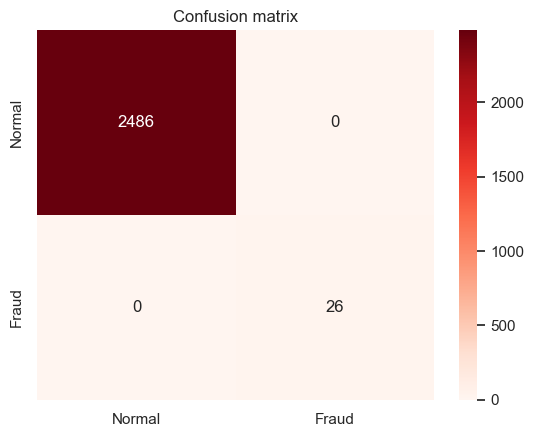

In [38]:
from sklearn.metrics import confusion_matrix
y_pred = df['isAnomaly'].map({-1:1, 1:0})
y_true = df['Anomaly_status'].map({'Normal': 0, 'Potential fraud': 1})
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title('Confusion matrix')
plt.show()

The model accurately predicted 2,486 transactions were true negatives i,e were normal while false positives were zero that is predicting a  normal transaction as fraud was zero

The model predicted 26 transactions as true negatives i.e it predicted 26 fraud cases fraud as fraud while false negatives tha is precicting a fraud transaction as normal was zero.

                             Shap analysis

 99%|===================| 2499/2512 [02:32<00:00]        

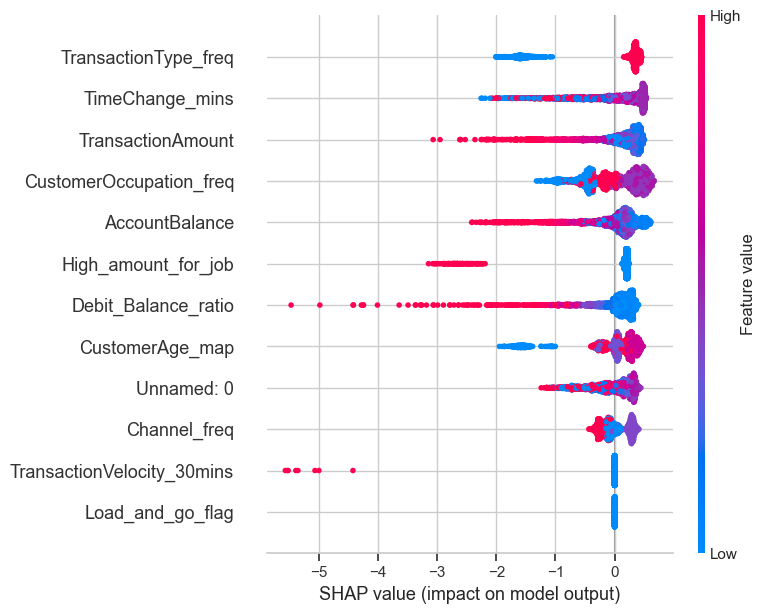

In [33]:
import shap
explainer = shap.Explainer(final_model, dff[features])
shap_values = explainer(dff[features])
shap.summary_plot(shap_values, dff[features])

the shap beeswarm plot shows Debit_balance_ratio, Account balance, Transaction velocity_30 mins, high_amount_for_job and transaction amount had the longest left tails showing their importance in a transaction being labelled a potential fraud. 
Influential factors like debit_balance_ratio had highest tails meaning the model's confidence in labelling a transaction fraud increased with the ratio, Transaction velocity under 30 minutes had red dots left-most part of the plot showing the model flagged those transactions occurring with intervals less than 30 minutes transactions as susspicious and high_amount_for_job has a distinct jump in red dots showing the model flagged transactions amounts which were greater than the threshold as potential frauds. 

account balance has long red left tail with a shorter right blue tail confirming the model viewed that an account balanceh aving high balances isn't fraud by itself but when influential factors like debit_balance_ratio, transactionvelocity_30mins etc are involved, then a transaction is considered as potential fraud.

                                 How the model confirmed the first transaction was a potential fraud 

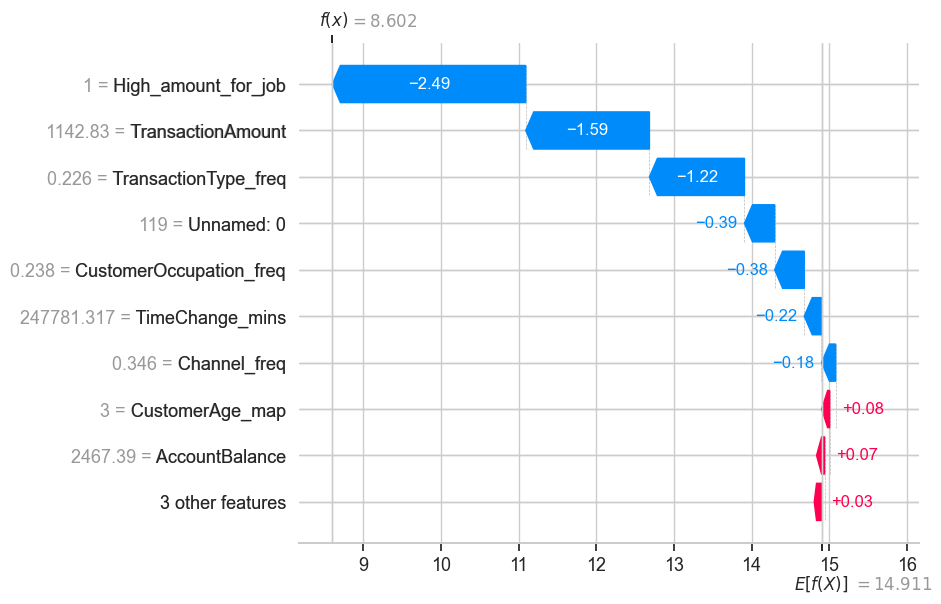

In [34]:
anomaly_index = df[df['isAnomaly'] == -1].index[0]
shap.plots.waterfall(shap_values[anomaly_index])

On this transaction, High_amount_for_job is the strongest driver of anomaly with (-2.49) showing that the model flagged this transaction as fraud since the transaction amount is unusually high, Transaction amount comes second with 1,142 showing the amount is high than the the norm contributing a -1.59 push and transactiontype_freq coming at -1.22 shows the rarity of this transaction at 0.226 is  amking it to be considered an anomaly.

An account balance of 2, 467 provides a buffer of +0.03 before this transaction is considered fraud. This means the model acknowledges that there is an amount to cover a transaction as not fraud even if the said transaction amount is high. 

NB: The E[f{X}] = 14.911 is the base value where the model adds or substracts confidence values based on features of a particular transaction

In [ ]:
original_df = pd.read_csv(r'./bank_transactions_data_2.csv')

In [ ]:

new_df = df.merge(original_df[['TransactionID', 'AccountID', 'Location', 'Channel']], on='TransactionID', how='left')
fraud_df = new_df[new_df['isAnomaly'] == -1].sort_values(by='Anomaly_score')
report_columns = ['AccountID','TransactionID','Channel', 'TransactionAmount', 'AccountBalance', 'Debit_Balance_ratio', 'Anomaly_score', 'Location']
fraud_df[report_columns].head()

,AccountID,TransactionID,Channel,TransactionAmount,AccountBalance,Debit_Balance_ratio,Anomaly_score,Location
157,AC00029,TX002087,Branch,1192.95,325.15,3.668922,-0.078011,Las Vegas
1424,AC00285,TX000312,Online,1221.65,243.92,5.008404,-0.061532,Denver
1513,AC00303,TX001985,Online,1512.99,9963.39,0.151855,-0.057898,Philadelphia
151,AC00028,TX002415,Branch,1664.33,1588.31,1.047862,-0.056828,San Antonio
1025,AC00205,TX001704,Branch,1294.81,9927.75,0.000000,-0.056289,Washington


In [ ]:
fraud_df.Channel.value_counts()

Channel
Branch    25
Online    16
ATM       10
Name: count, dtype: int64

In [ ]:
fraud_df.Location.value_counts().nlargest(10)

Location
Portland         3
Philadelphia     3
Austin           3
San Diego        3
Columbus         2
Oklahoma City    2
Memphis          2
Phoenix          2
Fort Worth       2
Miami            2
Name: count, dtype: int64